<a href="https://colab.research.google.com/github/bimaadiwijaya8/PCVK26_05_BimaAdiwijaya/blob/main/P5_Praktikum_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum E1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

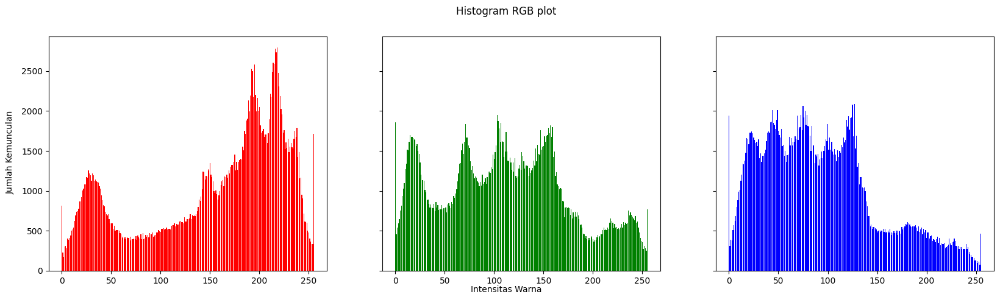

In [3]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

### PERTANYAAN PRAKTIKUM E1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

================ HASIL EVALUASI & PEMBUKTIAN ================
File: /content/drive/MyDrive/PCVK/Gambar/lena.jpg
Selisih Maksimum (Manual vs NumPy)  : 0
Selisih Maksimum (Manual vs OpenCV) : 0
Selisih Maksimum (NumPy vs OpenCV)  : 0



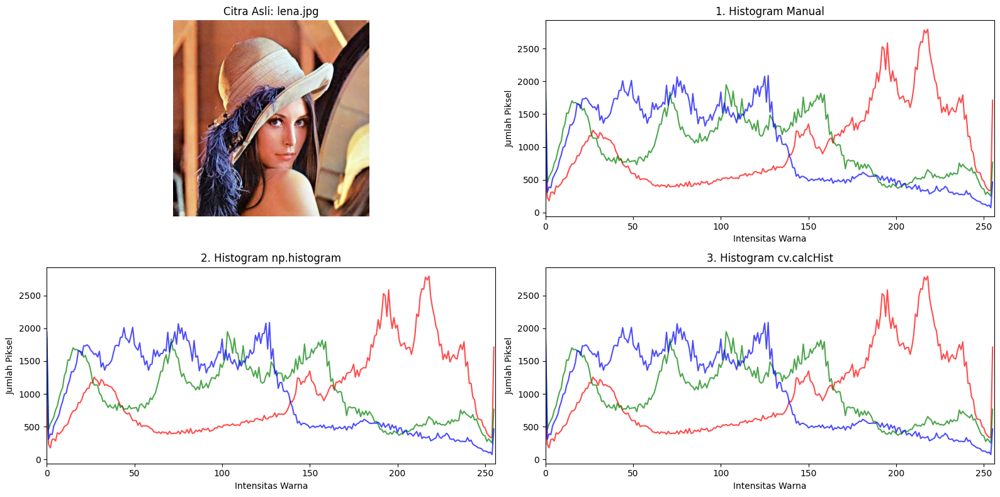

================ HASIL EVALUASI & PEMBUKTIAN ================
File: /content/drive/MyDrive/PCVK/Gambar/ktp1.jpg
Selisih Maksimum (Manual vs NumPy)  : 0
Selisih Maksimum (Manual vs OpenCV) : 0
Selisih Maksimum (NumPy vs OpenCV)  : 0



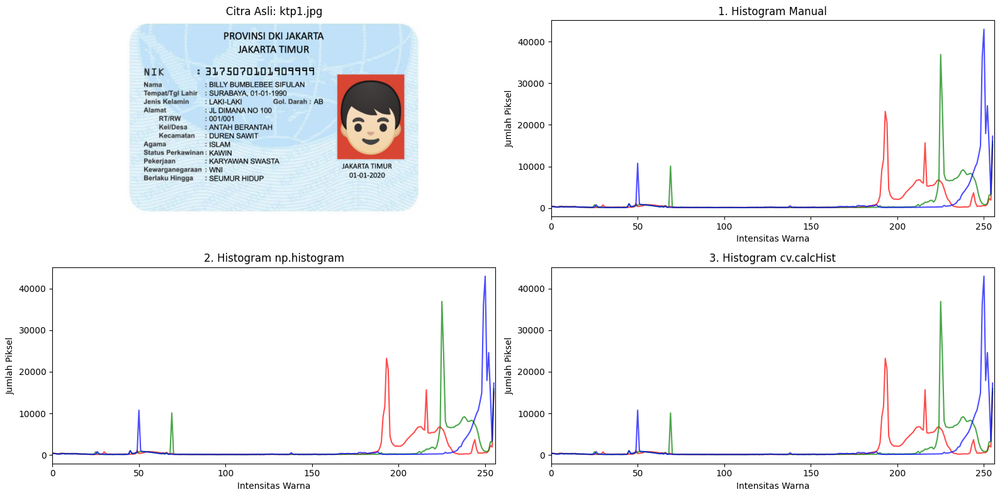

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def proses_dan_bandingkan(path_gambar):
    # 1. Baca Citra
    img_bgr = cv.imread(path_gambar)
    if img_bgr is None:
        print(f"Gambar tidak ditemukan pada path: {path_gambar}")
        return

    # Konversi BGR ke RGB
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    height, width, _ = img_rgb.shape

    # -------------------------------------------------------------
    # 2. Perhitungan Histogram
    # -------------------------------------------------------------
    # A. Histogram Manual
    hist_manual = np.zeros((3, 256), dtype=np.int64)
    for y in range(height):
        for x in range(width):
            hist_manual[0, img_rgb[y, x, 0]] += 1  # Red
            hist_manual[1, img_rgb[y, x, 1]] += 1  # Green
            hist_manual[2, img_rgb[y, x, 2]] += 1  # Blue

    # B. Histogram dengan np.histogram
    hist_numpy = np.zeros((3, 256), dtype=np.int64)
    for c in range(3):
        hist, _ = np.histogram(img_rgb[:, :, c], bins=256, range=(0, 256))
        hist_numpy[c] = hist

    # C. Histogram dengan cv.calcHist
    hist_opencv = np.zeros((3, 256), dtype=np.int64)
    for c in range(3):
        hist = cv.calcHist([img_rgb], [c], None, [256], [0, 256])
        hist_opencv[c] = hist.flatten()

    # -------------------------------------------------------------
    # 3. Hitung Pembuktian Selisih Maksimum (Harus = 0)
    # -------------------------------------------------------------
    diff_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
    diff_manual_opencv = np.max(np.abs(hist_manual - hist_opencv))
    diff_numpy_opencv = np.max(np.abs(hist_numpy - hist_opencv))

    print(f"================ HASIL EVALUASI & PEMBUKTIAN ================")
    print(f"File: {path_gambar}")
    print(f"Selisih Maksimum (Manual vs NumPy)  : {diff_manual_numpy}")
    print(f"Selisih Maksimum (Manual vs OpenCV) : {diff_manual_opencv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV)  : {diff_numpy_opencv}")
    print("=" * 60 + "\n")

    # -------------------------------------------------------------
    # 4. Visualisasi Citra dan Plot Histogram
    # -------------------------------------------------------------
    fig = plt.figure(figsize=(16, 8))

    # Menampilkan Citra Asli
    ax_img = fig.add_subplot(2, 2, 1)
    ax_img.imshow(img_rgb)
    ax_img.set_title(f"Citra Asli: {path_gambar.split('/')[-1]}")
    ax_img.axis('off')

    # Plot Histogram Manual
    ax_man = fig.add_subplot(2, 2, 2)
    colors = ('red', 'green', 'blue')
    for c, color in enumerate(colors):
        ax_man.plot(hist_manual[c], color=color, alpha=0.7)
    ax_man.set_title("1. Histogram Manual")
    ax_man.set_xlim([0, 256])
    ax_man.set_xlabel("Intensitas Warna")
    ax_man.set_ylabel("Jumlah Piksel")

    # Plot Histogram NumPy
    ax_num = fig.add_subplot(2, 2, 3)
    for c, color in enumerate(colors):
        ax_num.plot(hist_numpy[c], color=color, alpha=0.7)
    ax_num.set_title("2. Histogram np.histogram")
    ax_num.set_xlim([0, 256])
    ax_num.set_xlabel("Intensitas Warna")
    ax_num.set_ylabel("Jumlah Piksel")

    # Plot Histogram OpenCV
    ax_cv = fig.add_subplot(2, 2, 4)
    for c, color in enumerate(colors):
        ax_cv.plot(hist_opencv[c], color=color, alpha=0.7)
    ax_cv.set_title("3. Histogram cv.calcHist")
    ax_cv.set_xlim([0, 256])
    ax_cv.set_xlabel("Intensitas Warna")
    ax_cv.set_ylabel("Jumlah Piksel")

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# Eksekusi untuk lena.jpg dan ktp1.jpg
# -------------------------------------------------------------
path_base = '/content/drive/MyDrive/PCVK/Gambar/'

# Pembuktian untuk lena.jpg
proses_dan_bandingkan(path_base + 'lena.jpg')

# Pembuktian untuk ktp1.jpg
proses_dan_bandingkan(path_base + 'ktp1.jpg')

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

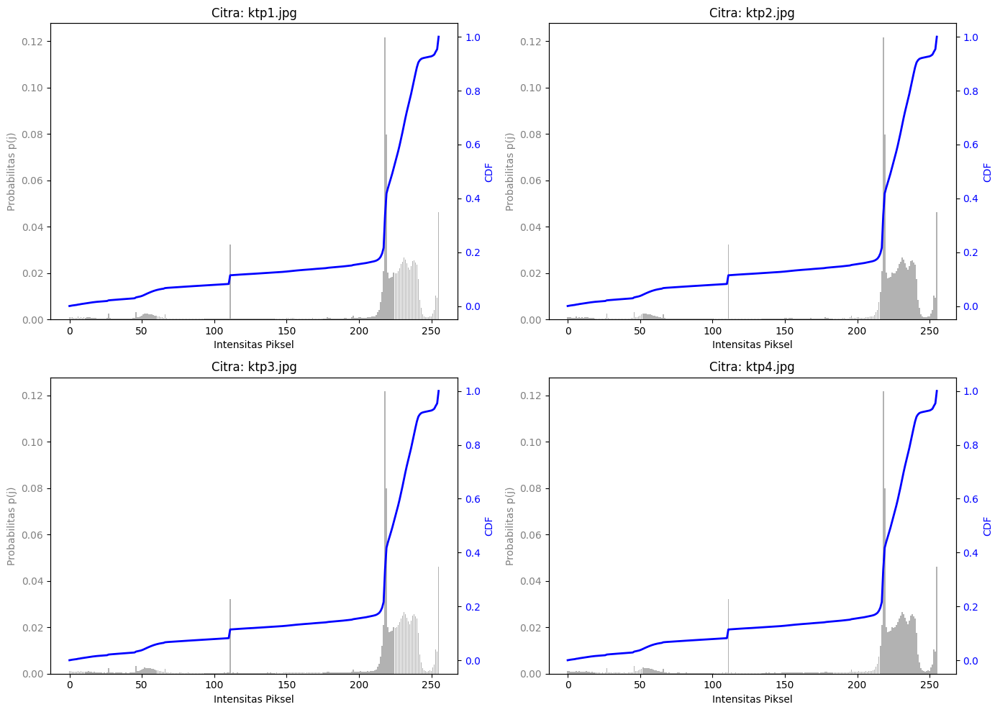

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

images = ['ktp1.jpg', 'ktp2.jpg', 'ktp3.jpg', 'ktp4.jpg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for i, img_name in enumerate(images):
    path = path_base + img_name
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)  # Menggunakan citra grayscale

    if img is None:
        continue

    # Hitung histogram ternormalisasi p(j)
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    p_j = hist / img.size

    # Hitung CDF (Cumulative Distribution Function)
    cdf = p_j.cumsum()

    # Plotting Histogram Ternormalisasi & CDF
    ax1 = axs[i]
    ax1.bar(np.arange(256), p_j, color='gray', alpha=0.6, label='p(j) (Histogram)')
    ax1.set_xlabel('Intensitas Piksel')
    ax1.set_ylabel('Probabilitas p(j)', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')

    ax2 = ax1.twinx()
    ax2.plot(cdf, color='blue', linewidth=2, label='CDF')
    ax2.set_ylabel('CDF', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    ax1.set_title(f'Citra: {img_name}')

plt.tight_layout()
plt.show()

### **Analisis Hasil Histogram Ternormalisasi p(j) dan Kurva CDF (Soal No. 2)**

Berdasarkan hasil plot histogram ternormalisasi $p(j)$ dan kurva *Cumulative Distribution Function* (CDF) pada citra `ktp1.jpg` hingga `ktp4.jpg` di atas:

1. **Karakteristik Distribusi Piksel:**
   - Mayoritas piksel pada semua citra berkumpul di area intensitas tinggi/terang (nilai intensitas berkisar antara **200 hingga 255**), ditandai dengan puncak histogram yang tinggi serta kemiringan kurva CDF yang melonjak sangat tajam di area tersebut.
   - Terdapat puncak spesifik (spike) pada intensitas sekitar **110** dan **218**, yang menunjukkan adanya area dengan warna latar belakang atau objek dominan dengan nilai derajat keabuan yang seragam.

2. **Perbandingan Kurva CDF Citra Gelap vs Terang:**
   - **Citra Paling Terang:** Kurva CDF cenderung sangat landai di area intensitas rendah hingga menengah (0–200) dan baru naik secara signifikan hingga mencapai nilai $1.0$ pada area terang (>200). Ini menunjukkan sebagian besar informasi warna/pencahayaan berada di rentang terang.
   - **Citra Paling Gelap:** Kurva CDF menunjukkan peningkatan nilai kumulatif lebih awal (di sekitar intensitas 0–100) sebelum akhirnya mengalami kenaikan tajam di area terang.

3. **Keterkaitan dengan Kondisi Pencahayaan Akuisisi:**
   - Kurva CDF dan histogram yang mendominasi sisi kanan (intensitas tinggi) mengindikasikan bahwa proses akuisisi citra dilakukan dalam **kondisi pencahayaan yang terang (*high-key* / cenderung overexposure)** atau latar belakang objek akuisisi memiliki warna yang cenderung putih/terang.
   - Kurva CDF yang melandai di rentang pertengahan menunjukkan kurangnya kontras pada area *mid-tones*, di mana sebagian besar detail gambar terkonsentrasi pada area terang.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

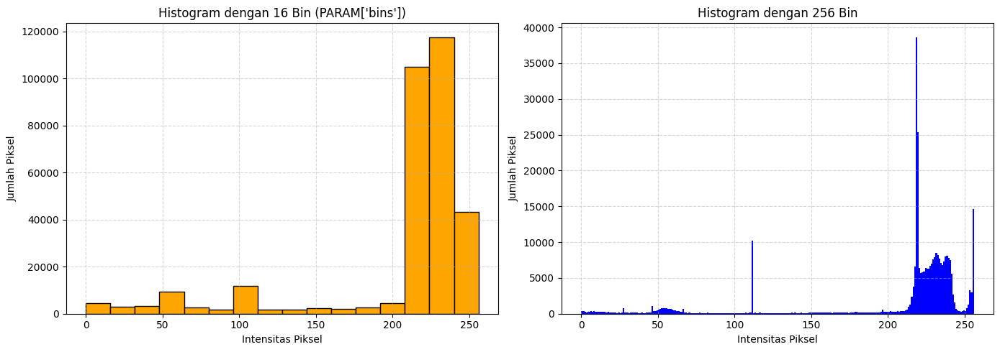

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Definisi parameter
PARAM = {'bins': 16}  # Ubah nilai ini sesuai instruksi praktikum (misal: 16, 32, atau 64)

# Path gambar (sesuai file ktp/KTM Anda)
path_gambar = '/content/drive/MyDrive/PCVK/Gambar/ktp2.jpg'

img = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Gambar tidak ditemukan pada path: {path_gambar}")
else:
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Histogram dengan PARAM['bins']
    axs[0].hist(img.flatten(), bins=PARAM['bins'], range=(0, 256), color='orange', edgecolor='black')
    axs[0].set_title(f"Histogram dengan {PARAM['bins']} Bin (PARAM['bins'])")
    axs[0].set_xlabel('Intensitas Piksel')
    axs[0].set_ylabel('Jumlah Piksel')
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Histogram dengan 256 Bin
    axs[1].hist(img.flatten(), bins=256, range=(0, 256), color='blue', edgecolor='none')
    axs[1].set_title('Histogram dengan 256 Bin')
    axs[1].set_xlabel('Intensitas Piksel')
    axs[1].set_ylabel('Jumlah Piksel')
    axs[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### **Analisis Hasil Histogram: 16 Bin (PARAM['bins']) vs 256 Bin (Soal No. 3)**

Berdasarkan grafik perbandingan histogram antara **16 Bin** dan **256 Bin** pada gambar di atas:

1. **Informasi Detail yang Hilang (Loss of Granularity):**
   - **Puncak Spesifik (Spikes):** Pada histogram **256 Bin**, terlihat jelas dua lonjakan sangat tajam (*sharp spikes*) di sekitar nilai intensitas **110** dan **218**, serta puncak di ujung **255**. Pada histogram **16 Bin**, lonjakan tajam ini sepenuhnya hilang dan melebur ke dalam kelompok bar yang lebar, sehingga kita tidak lagi mengetahui nilai kecerahan spesifik yang mendominasi citra.
   - **Variasi Gelombang Intensitas:** Distribusi kontras halus pada area terang (rentang intensitas **220–245**) yang tampak bergelombang pada 256 Bin menjadi tergeneralisasi hanya ke dalam 2 bar besar pada 16 Bin.

2. **Pengelompokan Piksel (Quantization Error):**
   - Pada 16 Bin, setiap bin menampung rentang nilai sebesar $\frac{256}{16} = 16$ tingkat keabuan. Akibatnya, frekuensi kumulatif per bin meningkat drastis (mencapai >100.000 piksel) karena piksel-piksel dengan derajat keabuan yang berbeda dipaksa masuk ke dalam satu kelompok (*binNING*).

3. **Kesimpulan:**
   - **Histogram 256 Bin** mempertahankan resolusi intensitas secara utuh (*fine-grained*), memungkinkan analisis fitur-fitur kecil, kontras detail, dan nilai intensitas dominan yang presisi.
   - **Histogram 16 Bin** hanya memberikan gambaran umum (*coarse-grained*) terkait sebaran global pencahayaan citra (bahwa citra mendominasi area terang di sisi kanan), namun kehilangan seluruh detail nilai keabuan spesifik dan variasi lokal.

# Praktikum E2

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

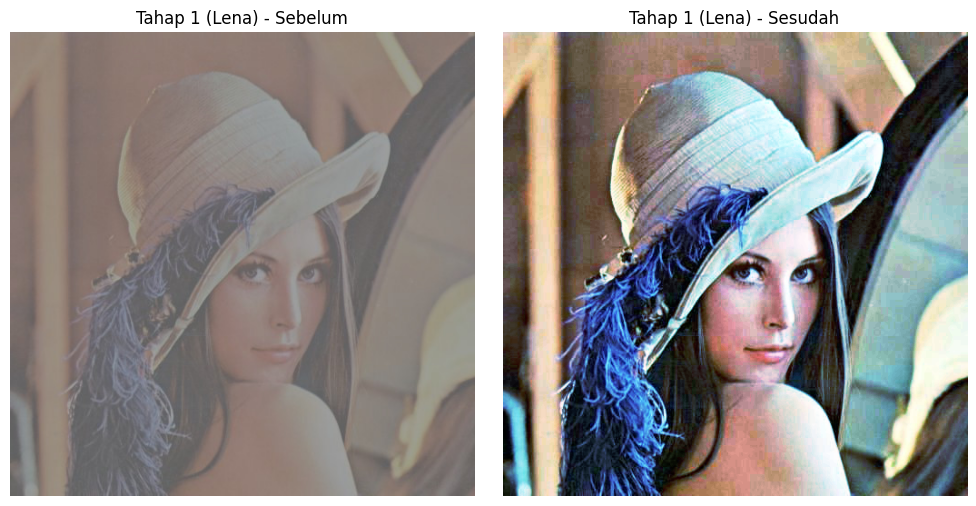

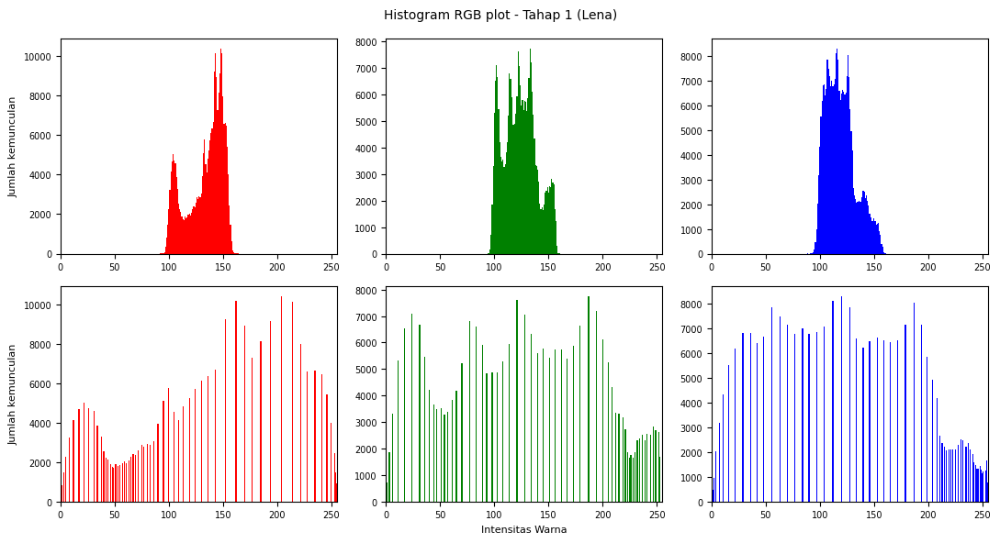

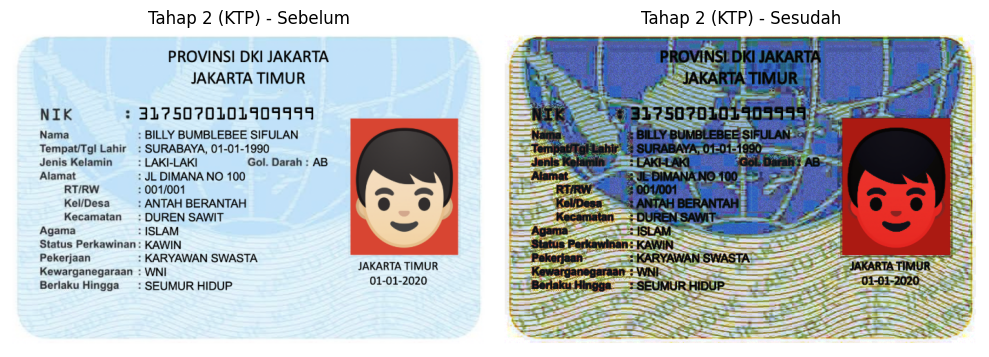

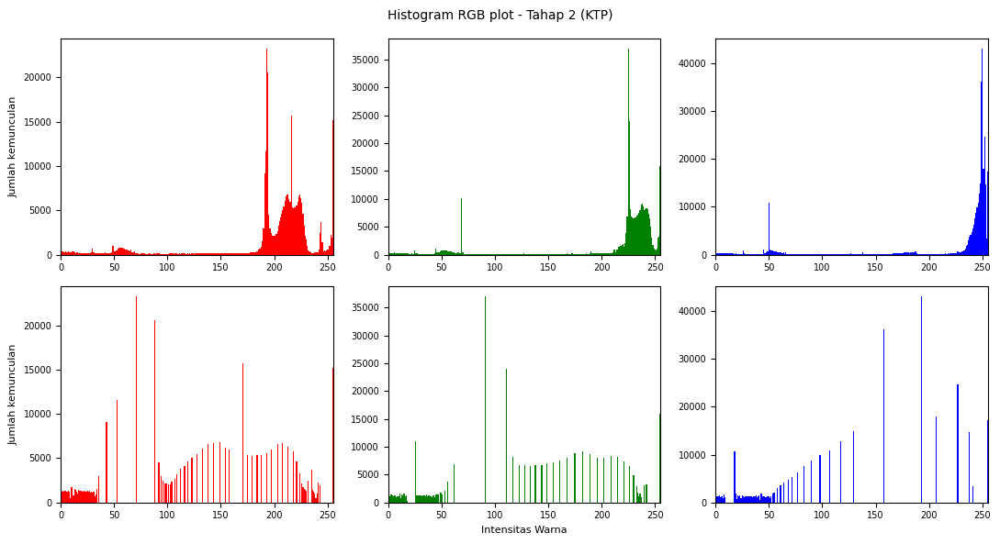

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

L = 256  # jumlah level intensitas (0..255)

# ---------- Histogram Equalization (sesuai flowchart) ----------
def equalize_channel(ch):
    total_pixel = ch.size
    freq = np.bincount(ch.ravel(), minlength=L)
    cdf = np.cumsum(freq) / total_pixel
    lut = np.round((L - 1) * cdf).astype(np.uint8)
    return lut[ch]

def equalize_rgb(img):
    out = np.zeros_like(img)
    for c in range(3):
        out[:, :, c] = equalize_channel(img[:, :, c])
    return out

# ---------- Tampilan ----------
def tampilkan(before, after, judul):
    # Citra sebelum dan sesudah
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(before); ax[0].set_title(f"{judul} - Sebelum"); ax[0].axis("off")
    ax[1].imshow(after);  ax[1].set_title(f"{judul} - Sesudah"); ax[1].axis("off")
    plt.tight_layout(); plt.show()

    # Histogram RGB (baris atas: sebelum, baris bawah: sesudah)
    warna = ["red", "green", "blue"]
    fig, axes = plt.subplots(2, 3, figsize=(11, 6))
    fig.suptitle(f"Histogram RGB plot - {judul}", fontsize=10)
    for r, arr in enumerate([before, after]):
        for c in range(3):
            h = np.bincount(arr[:, :, c].ravel(), minlength=L)
            axes[r, c].bar(range(L), h, color=warna[c], width=1.0)
            axes[r, c].set_xlim(0, 255)
            axes[r, c].tick_params(labelsize=7)
            if c == 0:
                axes[r, c].set_ylabel("Jumlah kemunculan", fontsize=8)
            if r == 1 and c == 1:
                axes[r, c].set_xlabel("Intensitas Warna", fontsize=8)
    plt.tight_layout(); plt.show()

# ---------- Proses Tahap 1 dan Tahap 2 sekaligus ----------
folder = "/content/drive/MyDrive/PCVK/Gambar/"
daftar = [
    ("Tahap 1 (Lena)", folder + "lena_lc.jpg"),
    ("Tahap 2 (KTP)",  folder + "ktp2.jpg"),
]

for judul, path in daftar:
    before = np.array(Image.open(path).convert("RGB"), dtype=np.uint8)
    after = equalize_rgb(before)
    tampilkan(before, after, judul)
    Image.fromarray(after).save(folder + "hasil_" + path.split("/")[-1])

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.

Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.

 HASIL PERBANDINGAN: Tahap 1 (Lena)
Selisih Maksimum Nilai Piksel (OpenCV vs Manual): 0


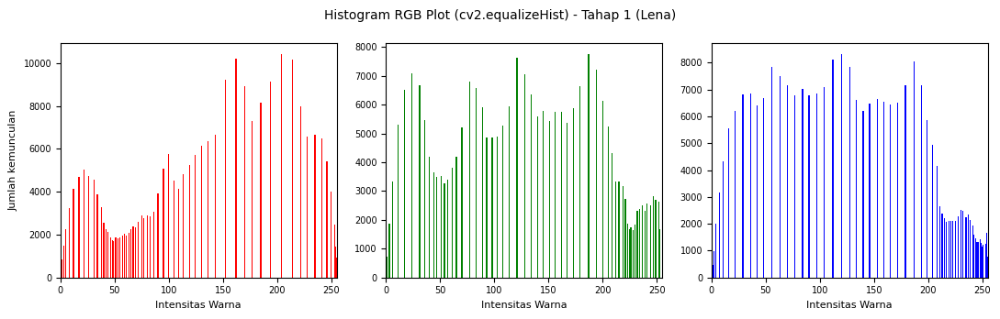

 HASIL PERBANDINGAN: Tahap 2 (KTM)
Selisih Maksimum Nilai Piksel (OpenCV vs Manual): 1


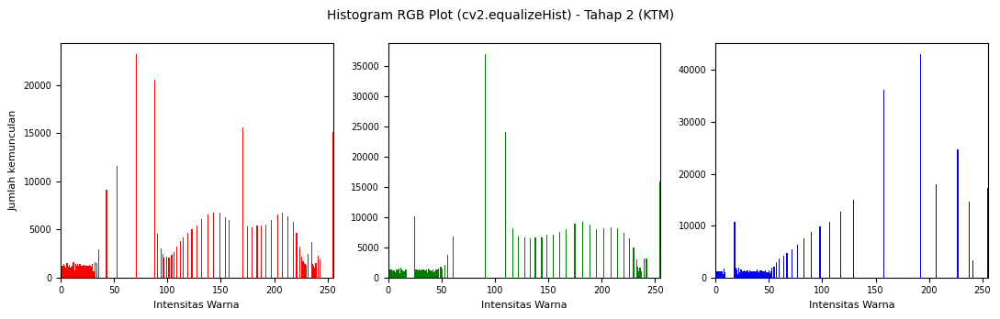

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

L = 256  # Jumlah level intensitas

# -------------------------------------------------------------------
# 1. Fungsi Equalization Manual (Dari Nomor 1)
# -------------------------------------------------------------------
def equalize_channel_manual(ch):
    total_pixel = ch.size
    freq = np.bincount(ch.ravel(), minlength=L)
    cdf = np.cumsum(freq) / total_pixel
    lut = np.round((L - 1) * cdf).astype(np.uint8)
    return lut[ch]

def equalize_rgb_manual(img_rgb):
    out = np.zeros_like(img_rgb)
    for c in range(3):
        out[:, :, c] = equalize_channel_manual(img_rgb[:, :, c])
    return out

# -------------------------------------------------------------------
# 2. Fungsi Equalization OpenCV (cv2.equalizeHist) - Nomor 2
# -------------------------------------------------------------------
def equalize_rgb_cv2(img_bgr):
    # Sesuai instruksi soal: split channel B, G, R
    b, g, r = cv2.split(img_bgr)

    b_equalized = cv2.equalizeHist(b)
    g_equalized = cv2.equalizeHist(g)
    r_equalized = cv2.equalizeHist(r)

    # Merge kembali channel BGR
    img_cv2_bgr = cv2.merge([b_equalized, g_equalized, r_equalized])
    return img_cv2_bgr

# -------------------------------------------------------------------
# 3. Fungsi Tampilan Histogram RGB
# -------------------------------------------------------------------
def tampilkan_histogram(arr_rgb, judul):
    warna = ["red", "green", "blue"]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    fig.suptitle(f"Histogram RGB Plot (cv2.equalizeHist) - {judul}", fontsize=10)

    for c in range(3):
        h = np.bincount(arr_rgb[:, :, c].ravel(), minlength=L)
        axes[c].bar(range(L), h, color=warna[c], width=1.0)
        axes[c].set_xlim(0, 255)
        axes[c].tick_params(labelsize=7)
        if c == 0:
            axes[c].set_ylabel("Jumlah kemunculan", fontsize=8)
        axes[c].set_xlabel("Intensitas Warna", fontsize=8)

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# 4. Eksekusi & Pembandingan Hasil (Lena & KTP)
# -------------------------------------------------------------------
folder = "/content/drive/MyDrive/PCVK/Gambar/"
daftar = [
    ("Tahap 1 (Lena)", folder + "lena_lc.jpg"),
    ("Tahap 2 (KTM)",  folder + "ktp2.jpg"),
]

for judul, path in daftar:
    # Read image dalam format BGR (bawaan OpenCV)
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"⚠️ File tidak ditemukan: {path}")
        continue

    # 1. Olah dengan OpenCV
    hasil_cv2_bgr = equalize_rgb_cv2(img_bgr)
    hasil_cv2_rgb = cv2.cvtColor(hasil_cv2_bgr, cv2.COLOR_BGR2RGB)

    # 2. Olah dengan Manual
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hasil_manual_rgb = equalize_rgb_manual(img_rgb)

    # 3. Hitung Selisih Maksimum
    selisih_maks = np.max(np.abs(hasil_cv2_rgb.astype(np.int16) - hasil_manual_rgb.astype(np.int16)))

    print(f"==================================================")
    print(f" HASIL PERBANDINGAN: {judul}")
    print(f"==================================================")
    print(f"Selisih Maksimum Nilai Piksel (OpenCV vs Manual): {selisih_maks}")

    # 4. Tampilkan Histogram OpenCV
    tampilkan_histogram(hasil_cv2_rgb, judul)

### 1. Hasil Selisih Maksimum
* **Selisih = 0**: Berarti hasil implementasi manual dan fungsi `cv2.equalizeHist()` memberikan nilai piksel yang **persis identik**.
* **Selisih = 1 (atau angka kecil lainnya)**: Menunjukkan adanya perbedaan tipis pada beberapa nilai piksel akibat faktor teknis pembulatan numerik.

---

### 2. Penyebab Selisih Apabila Tidak Nol
Jika terdapat perbedaan nilai antara hasil `cv2.equalizeHist()` dan fungsi manual, penyebab utamanya meliputi:

1. **Aturan Pembulatan (*Rounding Method*)**:
   * Pada fungsi manual digunakan `np.round()`, sedangkan algoritma internal C++ OpenCV pada `cv2.equalizeHist()` menggunakan metode pembulatan atau pemangkasan (*truncation*) berbasis `cv::saturate_cast<uchar>`.

2. **Formula Normalisasi CDF**:
   * Beberapa rumus manual menyertakan pengurangan nilai CDF minimum:
   $$\text{LUT}(v) = \text{round}\left( \frac{\text{CDF}(v) - \text{CDF}_{\min}}{N - \text{CDF}_{\min}} \times 255 \right)$$
   * Sedangkan `cv2.equalizeHist()` menggunakan formula akumulasi standar langsung terhadap total piksel $N$:
   $$\text{LUT}(v) = \text{round}\left( \frac{\text{CDF}(v)}{N} \times 255 \right)$$

3. **Format Ruang Warna (*Color Space*)**:
   * OpenCV membaca citra dalam urutan kanal **BGR**, sedangkan library PIL membaca citra secara default dalam urutan **RGB**. Perbedaan urutan kanal ini dapat menghasilkan selisih jika tidak disesuaikan terlebih dahulu.

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

=== TAHAP 1: lena.jpg ===


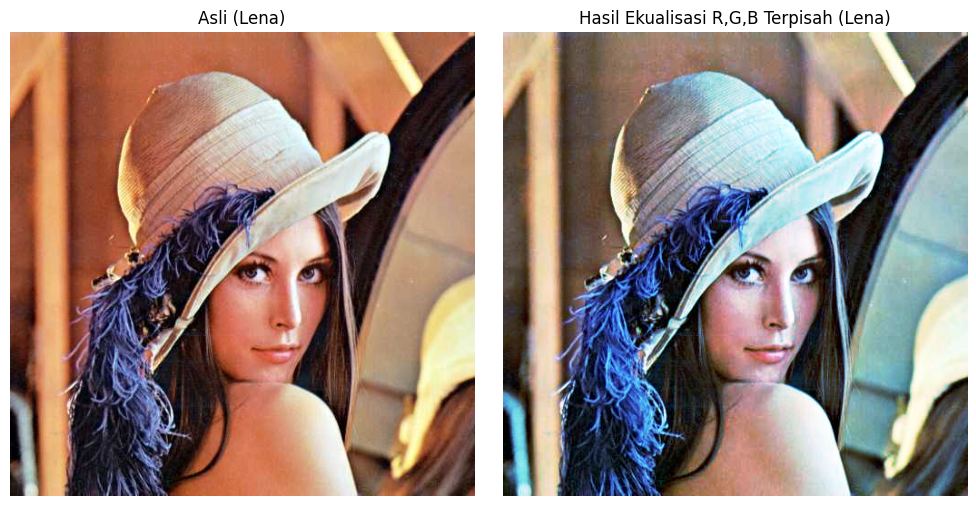

=== TAHAP 2: ktp1.jpg ===


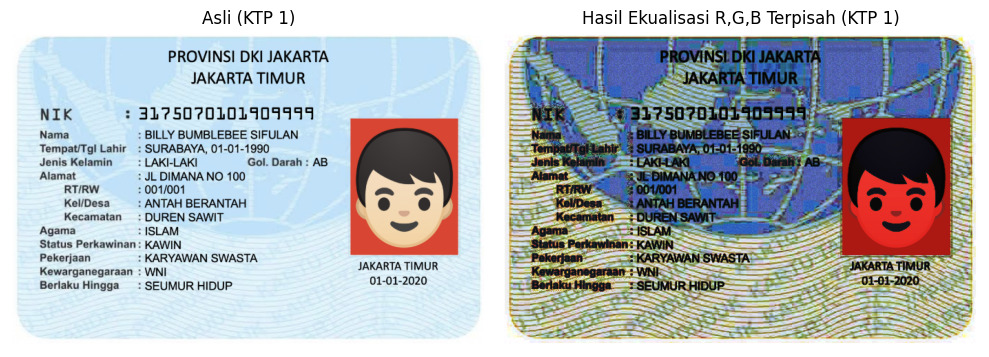

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path folder penyimpanan gambar di Google Drive
CONTOH = '/content/drive/MyDrive/PCVK/Gambar'
BASE = '/content/drive/MyDrive/PCVK/Gambar'

def proses_nomor_3(path_berkas, judul):
    # Read gambar (format BGR)
    bgr = cv.imread(path_berkas)
    if bgr is None:
        print(f"⚠️ Berkas tidak ditemukan: {path_berkas}")
        return

    # -------------------------------------------------------------
    # Potongan kode sesuai instruksi Soal No. 3
    # -------------------------------------------------------------
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_bgr = cv.merge(kanal)

    # Konversi BGR ke RGB untuk visualisasi Matplotlib
    orig_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    he_rgb = cv.cvtColor(he_bgr, cv.COLOR_BGR2RGB)

    # -------------------------------------------------------------
    # Tampilkan Citra Asli vs Hasil Ekualisasi Per Kanal
    # -------------------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(orig_rgb)
    ax[0].set_title(f"Asli ({judul})")
    ax[0].axis('off')

    ax[1].imshow(he_rgb)
    ax[1].set_title(f"Hasil Ekualisasi R,G,B Terpisah ({judul})")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# Eksekusi Tahap 1 (lena.jpg) dan Tahap 2 (ktp1.jpg)
# -------------------------------------------------------------
print("=== TAHAP 1: lena.jpg ===")
proses_nomor_3(CONTOH + '/lena.jpg', 'Lena')

print("=== TAHAP 2: ktp1.jpg ===")
proses_nomor_3(BASE + '/ktp1.jpg', 'KTP 1')

### Analisis Pengamatan Warna (Soal No. 3)

1. **Distorsi Warna (*Color Shift / False Color*)**:
   * Mengekualisasi kanal Merah ($R$), Hijau ($G$), dan Biru ($B$) secara terpisah menyebabkan **keseimbangan warna (*color balance*) rusak**.
   * Akibatnya, timbul warna tidak alami (*false color*) pada citra, seperti munculnya warna keperakan/kebiruan berlebih atau pergeseran nada warna yang sangat kontras.

2. **Pengamatan pada `lena.jpg` dan `ktp1.jpg`**:
   * **`lena.jpg`**: Nada warna (*tint*) kulit dan topi berubah drastis menjadi agak kebiruan/keunguan serta tampak terlalu kontras.
   * **`ktp1.jpg`**: Area teks, foto, dan latar belakang kartu mengalami pergeseran warna yang tajam. Latar belakang yang semula gelap/berwarna netral berubah memiliki pendaran warna (*artifact*) yang tidak alami.

3. **Penyebab Teoretis**:
   * Ekualisasi histogram pada ruang warna RGB mengubah distribusi frekuensi tiap saluran secara independen, sehingga nilai rasio rona warna (*hue*) dan kejenuhan (*saturation*) ikut bergeser.
   * **Solusi Terbaik**: Mengekualisasi citra berwarna sebaiknya dilakukan pada ruang warna yang memisahkan intensitas/pencahayaan dari warna, seperti **HSV** (hanya mengekualisasi kanal $V$) atau **Lab** (hanya mengekualisasi kanal $L$).

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)

Cara ekualisasi            Geser Hue (derajat) Rerata kecerahan
Citra asli                                  -            207.5
Ekualisasi kanal B, G, R                28.38            131.7
Kanal Y (YCrCb)                          1.08            132.4
Kanal V (HSV)                            1.09            124.2
Kanal L (LAB)                            1.86            126.3

[1] Geser Hue terbesar: "Ekualisasi kanal B, G, R" = 28.38 derajat

[2] Piksel gelap (V asli < 50): 3.2% dari citra
    Kanal Y (YCrCb)      geser Hue piksel gelap =  6.99 | piksel terang =  0.88 | tambahan piksel jenuh 255 = -1.30%
    Kanal V (HSV)        geser Hue piksel gelap = 10.64 | piksel terang =  0.78 | tambahan piksel jenuh 255 = +0.00%
    Kanal L (LAB)        geser Hue piksel gelap = 17.89 | piksel terang =  1.34 | tambahan piksel jenuh 255 = -0.91%

[3] Geser Hue terkecil di antara Y, V, L: "Kanal Y (YCrCb)" (1.08). Konfirmasi dengan mata pada gambar di bawah.

[4] Kanal terpilih: YCrCb
Cara        

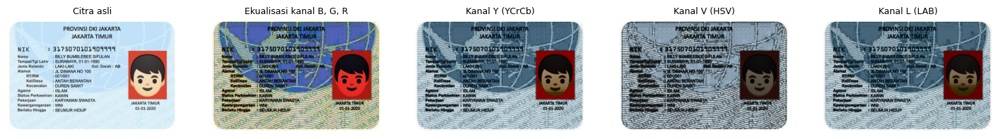

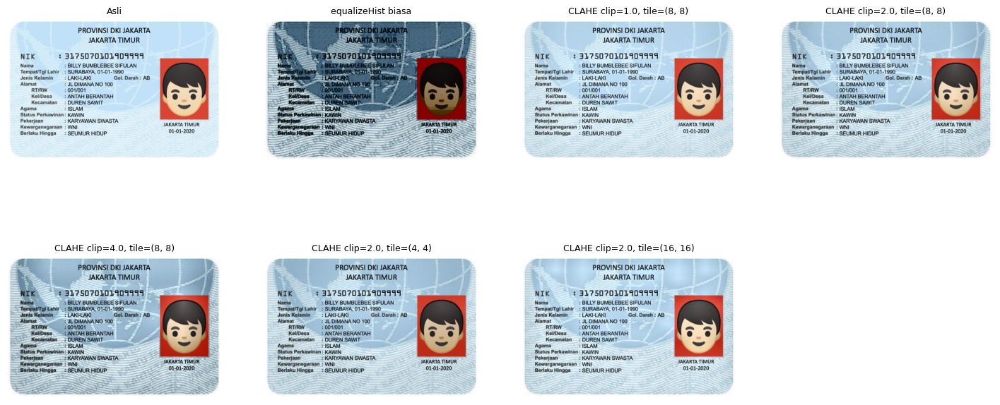

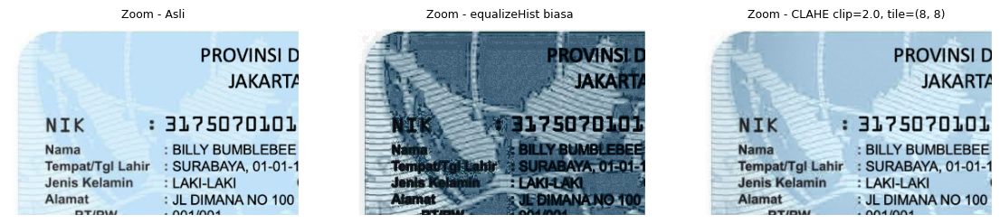

In [13]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

path = '/content/drive/MyDrive/PCVK/Gambar/ktp1.jpg'
bgr = cv.imread(path)
assert bgr is not None, 'Gambar tidak ditemukan, cek path-nya'

# ---------- fungsi bantu ----------
def geser_hue(asli, hasil, mask=None):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)              # Hue melingkar 0-179
    return d.mean() if mask is None else d[mask].mean()

def terang(c):
    return cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()

KODE = {'YCrCb': (cv.COLOR_BGR2YCrCb, cv.COLOR_YCrCb2BGR),
        'HSV':   (cv.COLOR_BGR2HSV,   cv.COLOR_HSV2BGR),
        'LAB':   (cv.COLOR_BGR2LAB,   cv.COLOR_LAB2BGR)}
IDX = {'YCrCb': 0, 'HSV': 2, 'LAB': 0}     # indeks kanal terang: Y, V, L

def proses(ruang, fn):
    a, b = KODE[ruang]
    ch = list(cv.split(cv.cvtColor(bgr, a)))
    ch[IDX[ruang]] = fn(ch[IDX[ruang]])
    return cv.cvtColor(cv.merge(ch), b)

# ---------- cara-cara ekualisasi ----------
kb = [cv.equalizeHist(k) for k in cv.split(bgr)]
he_rgb = cv.merge(kb)
he_y = proses('YCrCb', cv.equalizeHist)
he_v = proses('HSV',   cv.equalizeHist)
he_l = proses('LAB',   cv.equalizeHist)

judul = ['Citra asli', 'Ekualisasi kanal B, G, R', 'Kanal Y (YCrCb)', 'Kanal V (HSV)', 'Kanal L (LAB)']
citra = [bgr, he_rgb, he_y, he_v, he_l]

# ---------- TABEL ----------
print('%-26s %18s %16s' % ('Cara ekualisasi', 'Geser Hue (derajat)', 'Rerata kecerahan'))
gh = {}
for t, c in zip(judul, citra):
    gh[t] = None if t == 'Citra asli' else geser_hue(bgr, c)
    print('%-26s %18s %16.1f' % (t, '-' if gh[t] is None else '%.2f' % gh[t], terang(c)))

# ---------- JAWABAN 1 ----------
kandidat = {t: v for t, v in gh.items() if v is not None}
t_max = max(kandidat, key=kandidat.get)
print(f'\n[1] Geser Hue terbesar: "{t_max}" = {kandidat[t_max]:.2f} derajat')

# ---------- JAWABAN 2 (bukti pembulatan/pemotongan & piksel gelap) ----------
v_asli = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)[:, :, 2]
gelap = v_asli < 50
print(f'\n[2] Piksel gelap (V asli < 50): {gelap.mean()*100:.1f}% dari citra')
for t, c in zip(judul[2:], citra[2:]):
    sat255 = ((c == 255).any(axis=2).mean() - (bgr == 255).any(axis=2).mean()) * 100
    print(f'    {t:20s} geser Hue piksel gelap = {geser_hue(bgr, c, gelap):5.2f} | '
          f'piksel terang = {geser_hue(bgr, c, ~gelap):5.2f} | '
          f'tambahan piksel jenuh 255 = {sat255:+.2f}%')

# ---------- JAWABAN 3 (pilih otomatis; boleh Anda ganti manual) ----------
kanal3 = {'Kanal Y (YCrCb)': 'YCrCb', 'Kanal V (HSV)': 'HSV', 'Kanal L (LAB)': 'LAB'}
skor = {t: gh[t] for t in kanal3}
terbaik = min(skor, key=skor.get)
print(f'\n[3] Geser Hue terkecil di antara Y, V, L: "{terbaik}" ({skor[terbaik]:.2f}). '
      f'Konfirmasi dengan mata pada gambar di bawah.')
PILIH = kanal3[terbaik]      # ganti manual, misal PILIH = 'LAB', bila pengamatan visual Anda berbeda

# ---------- JAWABAN 4 : CLAHE pada kanal terpilih ----------
biasa = proses(PILIH, cv.equalizeHist)
print(f'\n[4] Kanal terpilih: {PILIH}')
print('%-34s %18s %16s' % ('Cara', 'Geser Hue (derajat)', 'Rerata kecerahan'))
print('%-34s %18.2f %16.1f' % ('equalizeHist biasa', geser_hue(bgr, biasa), terang(biasa)))

PARAM_LIST = [(1.0, (8, 8)), (2.0, (8, 8)), (4.0, (8, 8)), (2.0, (4, 4)), (2.0, (16, 16))]
hasil_clahe = []
for clip, tile in PARAM_LIST:
    PARAM = {'clip': clip, 'tile': tile}
    clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=PARAM['tile'])
    c = proses(PILIH, clahe.apply)
    hasil_clahe.append((f'CLAHE clip={clip}, tile={tile}', c))
    print('%-34s %18.2f %16.1f' % (f'CLAHE clip={clip}, tile={tile}', geser_hue(bgr, c), terang(c)))

# ---------- TAMPILAN ----------
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t, fontsize=9); plt.axis('off')
plt.show()

tampil = [('Asli', bgr), ('equalizeHist biasa', biasa)] + hasil_clahe
plt.figure(figsize=(18, 8))
for i, (t, c) in enumerate(tampil, 1):
    plt.subplot(2, 4, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t, fontsize=9); plt.axis('off')
plt.show()

# Zoom bagian tertentu (ubah koordinat ke area teks/foto/latar pada KTP Anda)
y1, y2, x1, x2 = 0, bgr.shape[0] // 2, 0, bgr.shape[1] // 2
plt.figure(figsize=(14, 4))
for i, (t, c) in enumerate([('Asli', bgr), ('equalizeHist biasa', biasa), hasil_clahe[1][0:2][0] and hasil_clahe[1]], 1):
    plt.subplot(1, 3, i); plt.imshow(cv.cvtColor(c[y1:y2, x1:x2], cv.COLOR_BGR2RGB))
    plt.title('Zoom - ' + t, fontsize=9); plt.axis('off')
plt.show()

## Nomor 4 – Ekualisasi Citra Berwarna (ktp1.jpg)

### Tabel Hasil

| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---|---|---|
| Citra asli | - | 207.5 | Kartu berwarna biru muda, terang, teks jelas terbaca, pas foto berlatar merah dengan warna kulit natural |
| Ekualisasi kanal B, G, R | 28.38 | 131.7 | Warna berubah drastis: latar kartu menjadi kehijauan/kekuningan, pas foto menjadi merah pekat (color cast), warna asli tidak dapat dikenali |
| Kanal Y (YCrCb) | 1.08 | 132.4 | Warna dasar biru tetap terjaga, tetapi kartu menjadi jauh lebih gelap dan pola peta di latar sangat menonjol; warna kulit di pas foto menjadi kecokelatan |
| Kanal V (HSV) | 1.09 | 124.2 | Hasil paling gelap dan cenderung keabu-abuan, pas foto gelap, kontras pola latar tinggi |
| Kanal L (LAB) | 1.86 | 126.3 | Mirip kanal Y, biru tua dan gelap, pola latar menonjol, warna kulit pas foto lebih gelap dari aslinya |

### Jawaban

**1. Cara dengan pergeseran Hue terbesar dan nilainya pada citra saya**

Ekualisasi kanal B, G, R dengan pergeseran Hue **28.38 derajat**, jauh di atas cara lain yang hanya sekitar 1-2 derajat. Hal ini terlihat jelas pada gambar: warna latar kartu berubah menjadi kehijauan dan pas foto menjadi merah pekat. Penyebabnya, setiap kanal (B, G, R) dipetakan dengan fungsi yang berbeda karena histogram masing-masing kanal berbeda. Akibatnya perbandingan B:G:R pada setiap piksel berubah, dan Hue ikut bergeser. Pada cara Y, V, dan L, kanal warnanya (Cr/Cb, H/S, a/b) tidak diubah sehingga perbandingan warna hampir terjaga.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak nol**

Kanal warna memang tidak diubah, tetapi pergeseran Hue tetap muncul karena:
- **Pembulatan** hasil konversi ruang warna ke bilangan bulat 8-bit, sehingga perbandingan B:G:R sedikit berubah setelah dikembalikan ke BGR.
- **Piksel gelap yang Hue-nya tidak stabil.** Pada piksel dengan V/S sangat kecil, selisih 1-2 level saja bisa mengubah Hue secara besar. Data saya menunjukkan piksel gelap (V asli < 50) hanya 3.2% dari citra, tetapi pergeseran Hue-nya jauh lebih besar dibanding piksel terang:
  - Kanal Y: 6.99 (gelap) vs 0.88 (terang)
  - Kanal V: 10.64 (gelap) vs 0.78 (terang)
  - Kanal L: 17.89 (gelap) vs 1.34 (terang)
- **Bukan karena clipping.** Jumlah piksel jenuh (255) tidak bertambah, bahkan berkurang (Y −1.30%, V +0.00%, L −0.91%). Jadi clipping ke 255 bukan penyebab utama pada citra ini.

Kanal L memiliki pergeseran Hue piksel gelap paling besar (17.89), sehingga rata-ratanya (1.86) lebih tinggi dibanding Y dan V.

**3. Kanal yang paling sesuai untuk foto KTP saya**

Kanal **Y (YCrCb)**. Alasannya:
- Pergeseran Hue rata-rata paling kecil (1.08 derajat).
- Pergeseran Hue pada piksel gelap juga paling kecil di antara Y, V, dan L (6.99, dibanding 10.64 pada V dan 17.89 pada L).
- Rerata kecerahan 132.4 berada di tengah rentang, sedangkan kanal V menghasilkan citra paling gelap (124.2).

Pengamatan pada gambar: pada kanal Y warna biru kartu masih dapat dikenali, dan teks pada area zoom (NIK, Nama, Tempat/Tgl Lahir, Jenis Kelamin) tetap terbaca. Namun perlu dicatat bahwa kartu menjadi jauh lebih gelap dari aslinya dan pola peta di latar ikut menguat sehingga sedikit mengganggu teks. Karena itu kanal Y saya pilih hanya berdasarkan kestabilan warna, bukan karena hasilnya paling bagus secara keseluruhan (lihat jawaban nomor 4).

**4. Perbandingan CLAHE dengan equalizeHist biasa (kanal Y)**

| Cara | Geser Hue (derajat) | Rerata kecerahan |
|---|---|---|
| equalizeHist biasa | 1.08 | 132.4 |
| CLAHE clip=1.0, tile=(8, 8) | 0.97 | 199.6 |
| CLAHE clip=2.0, tile=(8, 8) | 0.97 | 190.5 |
| CLAHE clip=4.0, tile=(8, 8) | 0.99 | 176.3 |
| CLAHE clip=2.0, tile=(4, 4) | 0.96 | 186.1 |
| CLAHE clip=2.0, tile=(16, 16) | 0.99 | 196.7 |

- **Pergeseran Hue** hampir sama pada semua cara (0.96-1.08 derajat). Selisihnya sangat kecil, jadi CLAHE tidak secara berarti lebih baik atau lebih buruk dalam menjaga warna, karena keduanya hanya mengubah kanal Y.
- **Kecerahan** adalah perbedaan utamanya. `equalizeHist` menurunkan kecerahan dari 207.5 ke 132.4 karena histogram diratakan ke seluruh rentang 0-255 sehingga rata-ratanya mendekati tengah. CLAHE menjaga kecerahan tetap tinggi (176.3-199.6), jauh lebih dekat ke citra asli, karena penguatan kontras dibatasi oleh clip limit dan dihitung per blok.
- **Pengamatan visual:** pada zoom, hasil `equalizeHist` menampilkan latar kartu yang gelap dengan pola peta yang sangat kontras, sehingga teks kurang nyaman dibaca. Hasil CLAHE (clip=2.0, tile=(8,8)) tetap terang, teks jelas terbaca, dan pola latar terlihat halus tanpa mengganggu.
- **Pengaruh `clipLimit`:** semakin besar clip (1.0 → 2.0 → 4.0), kecerahan turun (199.6 → 190.5 → 176.3) dan tekstur latar semakin menonjol karena kontras diperkuat lebih agresif, mendekati perilaku ekualisasi global.
- **Pengaruh `tileGridSize`:** dengan clip yang sama (2.0), tile (4,4) menghasilkan 186.1, (8,8) menghasilkan 190.5, dan (16,16) menghasilkan 196.7. Tile lebih kecil berarti adaptasi lebih lokal dan kecerahan sedikit lebih rendah.
- **Kesimpulan:** karena citra asli sudah terang, ekualisasi global (`equalizeHist`) justru menggelapkan hasil dan menonjolkan pola latar. CLAHE dengan clip kecil-sedang (1.0-2.0) lebih baik karena mempertahankan kecerahan, menambah kontras lokal secukupnya, dan menjaga Hue tetap stabil.

### PERTANYAAN PRAKTIKUM E2

In [14]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

path = '/content/drive/MyDrive/PCVK/Gambar/ktp1.jpg'
gray = cv.imread(path, cv.IMREAD_GRAYSCALE)      # versi grayscale
assert gray is not None, 'Gambar tidak ditemukan, cek path-nya'
L = 256

# Parameter CLAHE Anda (ganti sesuai nilai PARAM di modul/percobaan Anda)
PARAM = {'clip': 2.0, 'tile': 8}

def hist_gray(img):
    return np.bincount(img.ravel(), minlength=L)

def eq_manual(img):
    """Ekualisasi manual: frekuensi -> kumulatif -> normalisasi (dengan cdf_min, sama seperti OpenCV)."""
    freq = hist_gray(img)
    cum = np.cumsum(freq)
    N = img.size
    cmin = cum[freq > 0][0] if False else freq[freq > 0][0]
    lut = np.round((cum - cmin) * (L - 1) / (N - cmin))
    return np.clip(lut, 0, 255).astype(np.uint8)[img]

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

print('Ukuran citra:', gray.shape, '| rerata:', round(gray.mean(), 1), '| std:', round(gray.std(), 1))

Ukuran citra: (458, 694) | rerata: 207.5 | std: 55.5


1. Ekualisasi global pada citra KTM Anda
*   Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.
*   Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
*   Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

Selisih maks manual vs equalizeHist: 0


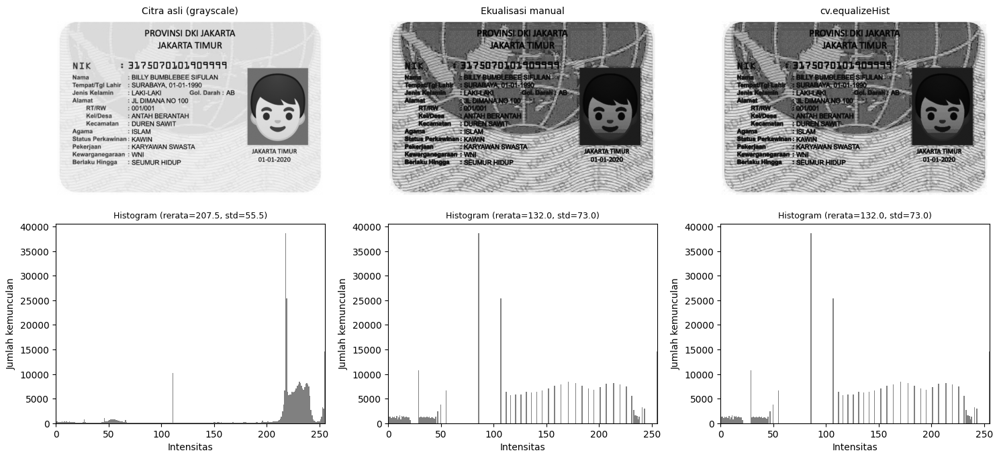

In [15]:
he_manual = eq_manual(gray)
he_cv = cv.equalizeHist(gray)

print('Selisih maks manual vs equalizeHist:', np.abs(he_manual.astype(int) - he_cv.astype(int)).max())

daftar = [('Citra asli (grayscale)', gray),
          ('Ekualisasi manual', he_manual),
          ('cv.equalizeHist', he_cv)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (judul, img) in enumerate(daftar):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(judul, fontsize=10); axes[0, i].axis('off')
    axes[1, i].bar(range(L), hist_gray(img), color='gray', width=1.0)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_xlabel('Intensitas'); axes[1, i].set_ylabel('Jumlah kemunculan')
    axes[1, i].set_title(f'Histogram (rerata={img.mean():.1f}, std={img.std():.1f})', fontsize=9)
plt.tight_layout(); plt.show()

In [16]:
print('%-22s %10s %10s %10s' % ('Pasangan', 'PSNR (dB)', 'Rerata', 'Std'))
print('%-22s %10s %10.1f %10.1f' % ('Asli', '-', gray.mean(), gray.std()))
for nama, img in [('Asli vs manual', he_manual), ('Asli vs equalizeHist', he_cv)]:
    print('%-22s %10.2f %10.1f %10.1f' % (nama, psnr(gray, img), img.mean(), img.std()))

# Pembanding: perubahan kecil (blur ringan) -> PSNR tinggi tetapi keterbacaan tidak membaik
blur = cv.GaussianBlur(gray, (3, 3), 0)
print('%-22s %10.2f %10.1f %10.1f' % ('Asli vs blur 3x3', psnr(gray, blur), blur.mean(), blur.std()))

Pasangan                PSNR (dB)     Rerata        Std
Asli                            -      207.5       55.5
Asli vs manual               9.10      132.0       73.0
Asli vs equalizeHist         9.10      132.0       73.0
Asli vs blur 3x3            26.44      207.5       50.8


2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
*   Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
*   Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.



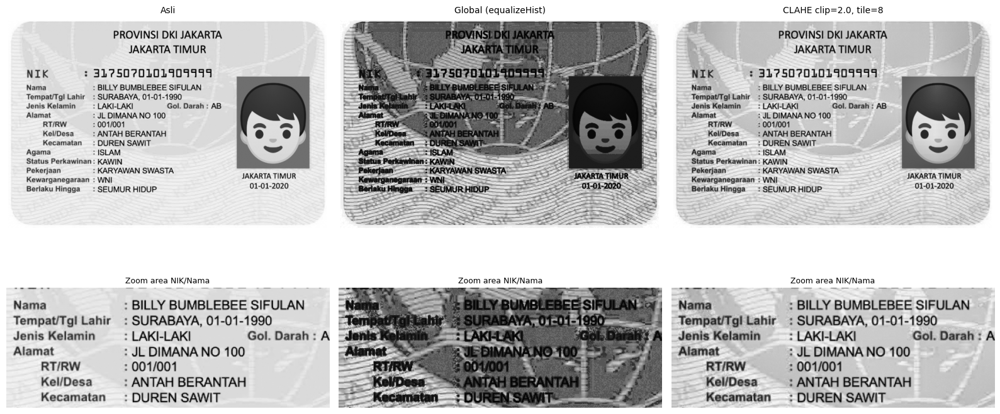

Kontras (std) area teks:
  Asli                           std = 54.7 | rerata = 200.5
  Global (equalizeHist)          std = 58.1 | rerata = 101.7
  CLAHE clip=2.0, tile=8         std = 53.5 | rerata = 184.1


In [17]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
cl = clahe.apply(gray)

# Area teks NIK dan Nama (pecahan dari ukuran citra; sesuaikan bila kurang pas)
H, W = gray.shape
y1, y2, x1, x2 = int(0.28*H), int(0.62*H), int(0.05*W), int(0.65*W)

hasil = [('Asli', gray), ('Global (equalizeHist)', he_cv),
         (f'CLAHE clip={PARAM["clip"]}, tile={PARAM["tile"]}', cl)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (t, img) in enumerate(hasil):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0, i].set_title(t, fontsize=10); axes[0, i].axis('off')
    axes[1, i].imshow(img[y1:y2, x1:x2], cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title('Zoom area NIK/Nama', fontsize=9); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Kontras (std) area teks:')
for t, img in hasil:
    print('  %-30s std = %.1f | rerata = %.1f' % (t, img[y1:y2, x1:x2].std(), img[y1:y2, x1:x2].mean()))

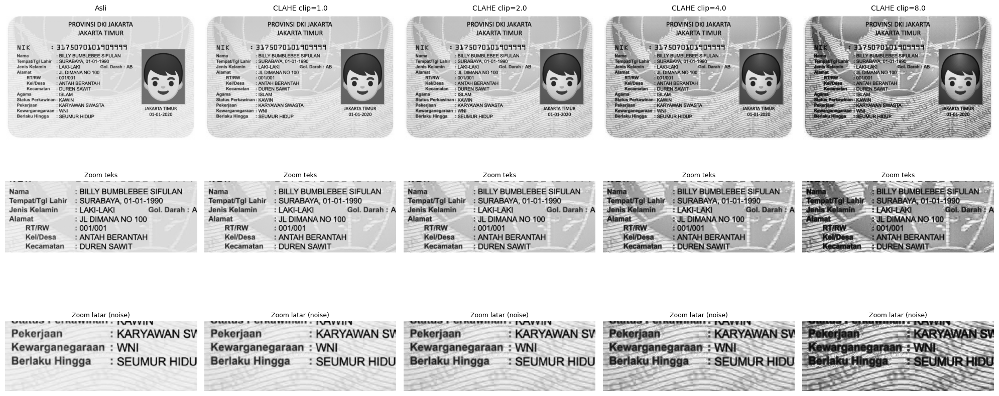

Cara                       Std teks Std latar (noise)   Rerata total
Asli                           54.7             55.9          207.5
CLAHE clip=1.0                 54.1             56.1          199.6
CLAHE clip=2.0                 53.5             56.7          190.5
CLAHE clip=4.0                 54.4             59.6          176.3
CLAHE clip=8.0                 58.7             67.6          158.8


In [18]:
c0 = PARAM['clip']
clip_uji = [c0 / 2, c0 * 2, c0 * 4]           # tiga nilai lain di sekitar nilai Anda
tile = (PARAM['tile'], PARAM['tile'])

# Area latar datar untuk mengamati noise (pilih bagian tanpa teks, sesuaikan koordinatnya)
ny1, ny2, nx1, nx2 = int(0.68*H), int(0.90*H), int(0.05*W), int(0.45*W)

semua = [(f'Asli', gray)] + [(f'CLAHE clip={c}', cv.createCLAHE(clipLimit=c, tileGridSize=tile).apply(gray))
                             for c in [c0/2, c0, c0*2, c0*4]]

fig, axes = plt.subplots(3, 5, figsize=(20, 9))
for i, (t, img) in enumerate(semua):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0, i].set_title(t, fontsize=10); axes[0, i].axis('off')
    axes[1, i].imshow(img[y1:y2, x1:x2], cmap='gray', vmin=0, vmax=255); axes[1, i].set_title('Zoom teks', fontsize=9); axes[1, i].axis('off')
    axes[2, i].imshow(img[ny1:ny2, nx1:nx2], cmap='gray', vmin=0, vmax=255); axes[2, i].set_title('Zoom latar (noise)', fontsize=9); axes[2, i].axis('off')
plt.tight_layout(); plt.show()

print('%-20s %14s %16s %14s' % ('Cara', 'Std teks', 'Std latar (noise)', 'Rerata total'))
for t, img in semua:
    print('%-20s %14.1f %16.1f %14.1f' % (t, img[y1:y2, x1:x2].std(), img[ny1:ny2, nx1:nx2].std(), img.mean()))

## Pertanyaan Praktikum E2

### 1. Ekualisasi global pada citra KTP (ktp1.jpg grayscale)

**a & b.** Ekualisasi manual (frekuensi → kumulatif → normalisasi dengan cdf_min) dan `cv.equalizeHist` menghasilkan citra yang identik: PSNR, rerata, dan std keduanya sama persis (selisih maksimum = [ISI dari output cell 1a]). Citra asli, hasil manual, hasil `equalizeHist`, dan histogramnya ditampilkan dalam satu layout. Histogram asli menumpuk di sisi terang (rerata 207.5, std 55.5), lalu menjadi lebih tersebar setelah ekualisasi (rerata 132.0, std 73.0).

**c. PSNR**

| Pasangan | PSNR (dB) | Rerata kecerahan | Std |
|---|---|---|---|
| Asli | - | 207.5 | 55.5 |
| Asli vs ekualisasi manual | 9.10 | 132.0 | 73.0 |
| Asli vs cv.equalizeHist | 9.10 | 132.0 | 73.0 |
| Asli vs blur 3×3 (pembanding) | 26.44 | 207.5 | 50.8 |

**Mengapa PSNR turun padahal citra terlihat lebih jelas?**
PSNR dihitung dari MSE, yaitu rata-rata kuadrat selisih nilai piksel antara dua citra, sehingga mengukur seberapa *mirip* citra hasil dengan citra asli, bukan seberapa *jelas* citra itu. Tujuan ekualisasi justru mengubah nilai piksel sebanyak mungkin: histogram diratakan ke seluruh rentang 0-255, dan kecerahan bergeser dari 207.5 menjadi 132.0 (std naik dari 55.5 menjadi 73.0). Perubahan besar ini membuat MSE besar dan PSNR hanya 9.10 dB. Jadi PSNR yang rendah adalah konsekuensi dari perubahan kontras, bukan tanda kualitas menurun.

**Apakah PSNR layak untuk menilai keterbacaan?**
Tidak layak sebagai ukuran tunggal. PSNR hanya menilai kedekatan terhadap citra referensi. Hal ini terlihat dari pembanding blur: blur 3×3 memberi PSNR 26.44 dB, jauh lebih tinggi daripada ekualisasi (9.10 dB), padahal blur justru menurunkan kontras (std turun dari 55.5 menjadi 50.8) dan tidak membuat teks lebih terbaca. PSNR cocok untuk menilai distorsi akibat kompresi atau noise ketika citra asli dianggap sempurna, tetapi tidak untuk peningkatan kontras. Untuk keterbacaan lebih tepat dipakai ukuran kontras (std, entropi), penilaian visual pada area teks, atau uji langsung seperti hasil OCR.

### 2. Ekualisasi lokal dengan CLAHE

**a. CLAHE vs ekualisasi global** (clipLimit = 2.0, tileGridSize = 8×8)

| Cara | Std area teks | Rerata area teks |
|---|---|---|
| Asli | 54.7 | 200.5 |
| Global (equalizeHist) | 58.1 | 101.7 |
| CLAHE | 53.5 | 184.1 |

Pada hasil **CLAHE** NIK dan nama lebih terbaca dibanding hasil global. Ekualisasi global meratakan histogram seluruh citra sekaligus, sehingga rerata area teks turun drastis dari 200.5 menjadi 101.7: latar yang tadinya terang menjadi gelap dan mendekati warna huruf, sementara pola peta pada latar ikut diperkuat. Std area teks memang naik menjadi 58.1, tetapi kenaikan itu berasal dari tekstur latar yang menguat, bukan dari huruf yang lebih tegas, sehingga std saja tidak menunjukkan keterbacaan yang lebih baik. CLAHE bekerja per blok dan membatasi penguatan lewat clipLimit, sehingga latar tetap terang (rerata 184.1) dan huruf gelap tetap terpisah jelas dari latar. Pada zoom area NIK/Nama, hasil global tampak gelap dengan pola peta yang menonjol, sedangkan hasil CLAHE tetap terang dengan teks terlihat mirip citra asli. Karena citra asli sudah memiliki kontras teks yang baik, CLAHE di sini lebih berfungsi menjaga keterbacaan daripada menambahnya.

**b. Variasi clipLimit**

| Cara | Std teks | Std latar (noise) | Rerata total |
| :--- | :---: | :---: | :---: |
| **Asli** | 54.7 | 55.9 | 207.5 |
| **CLAHE clip = 1.0** | 54.1 | 56.1 | 199.6 |
| **CLAHE clip = 2.0 (nilai awal)** | 53.5 | 56.7 | 190.5 |
| **CLAHE clip = 4.0** | 54.4 | 59.6 | 176.3 |
| **CLAHE clip = 8.0** | 58.7 | 67.6 | 158.8 |

**Nilai terbaik:** clipLimit = 2.0.
Alasan: pada nilai ini kontras teks tetap terjaga (std teks 53.5 dibanding 54.7 pada citra asli), noise/tekstur latar hampir tidak bertambah (std latar 56.7 dibanding 55.9), dan kecerahan turun secukupnya (190.5), yang menandakan pemerataan lokal sudah bekerja. Nilai 1.0 hampir tidak mengubah citra, sedangkan pada 4.0 std latar sudah naik menjadi 59.6 dan pada 8.0 melonjak menjadi 67.6 dengan kecerahan turun jauh (158.8). Kenaikan std teks pada clip 8.0 (58.7) tidak layak dianggap perbaikan karena datang bersamaan dengan naiknya std latar (+11.7 dari asli) dan gelapnya citra. Selisih std teks antara clip 1.0, 2.0, dan 4.0 sangat kecil (kurang dari 1), sehingga pemilihan 2.0 dilandasi terutama oleh kestabilan noise dan pengamatan visual.

**Bagian yang noise-nya mulai menonjol saat clipLimit dinaikkan:**
Area latar bagian bawah kiri kartu, yang berisi pola peta dan garis-garis halus (area zoom "latar"). Noise mulai terlihat pada clipLimit 4.0, ketika std latar naik dari 55.9 (asli) menjadi 59.6, dan jelas pada clipLimit 8.0 dengan std latar 67.6 dan pada zoom tampak tekstur yang berbintik dan kasar. Ini terjadi karena clipLimit membatasi seberapa tinggi histogram blok boleh dipotong. Semakin besar batasnya, semakin sedikit pemotongan, sehingga perbedaan kecil di area yang hampir seragam (termasuk noise dan pola halus latar) ikut diregangkan menjadi selisih yang terlihat.

# E-3 TUGAS PRAKTIKUM DITHERING

In [19]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/PCVK/Gambar'
PARAM = {'L': 2}          # jumlah level untuk KTP: ganti sesuai nilai PARAM['L'] Anda
L_LENA_WARNA = 4          # level per kanal untuk Lena berwarna (nomor 1); sesuaikan agar mirip gambar contoh
L_LENA_GRAY = 2           # sesuai gambar contoh nomor 2 ("Floyd-Steinberg, L = 2")

# numba (jika ada) supaya loop piksel cepat; kalau tidak ada tetap jalan, hanya lebih lambat
try:
    from numba import njit
except ImportError:
    def njit(f): return f

@njit
def _fs(img, step):
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.floor(lama / step + 0.5) * step      # round(lama/step) * step
            img[y, x] = baru
            err = lama - baru
            if x + 1 < W:
                img[y, x + 1] += err * 7 / 16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += err * 3 / 16
            if y + 1 < H:
                img[y + 1, x] += err * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += err * 1 / 16

def floyd_steinberg(gray, L):
    """Sesuai flowchart: float32 -> loop piksel -> sebar error -> clip 0-255 -> uint8."""
    img = gray.astype(np.float32)
    step = 255.0 / (L - 1)
    _fs(img, step)
    return np.clip(img, 0, 255).astype(np.uint8)

def fs_warna(bgr, L):
    """Citra berwarna: jalankan tiga kali (kanal B, G, R), lalu gabungkan."""
    return cv.merge([floyd_steinberg(k, L) for k in cv.split(bgr)])

def baca(path, mode=cv.IMREAD_COLOR):
    img = cv.imread(path, mode)
    assert img is not None, f'Gambar tidak ditemukan: {path}'
    return img

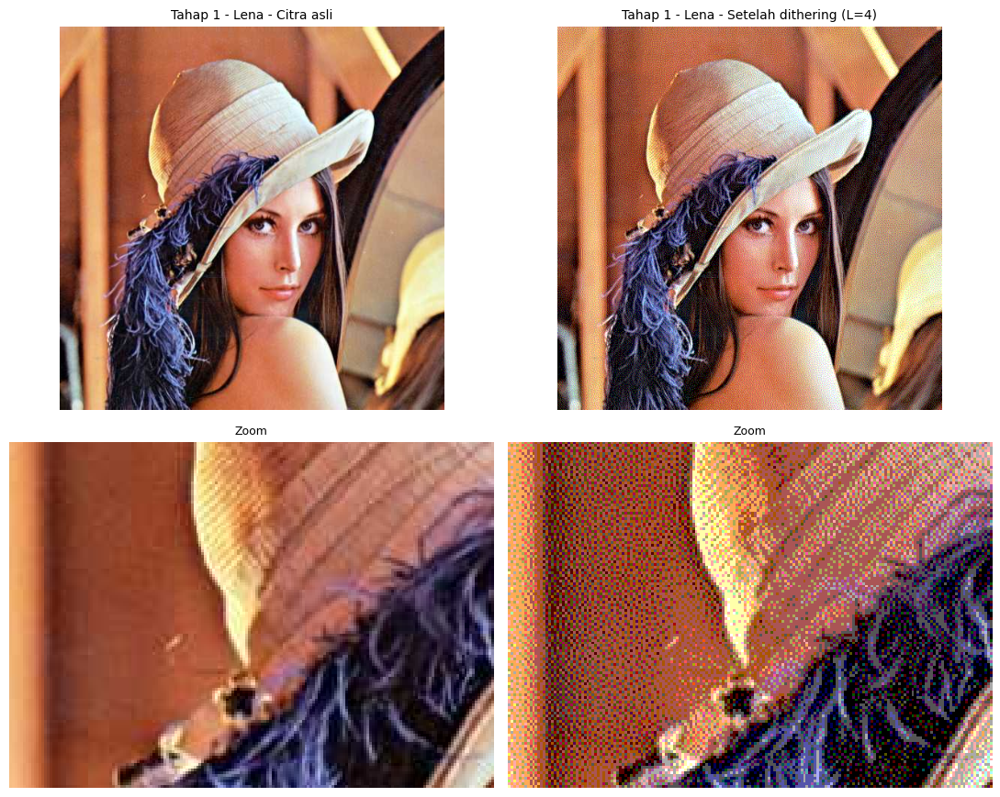

Tahap 1 - Lena: L = 4, jumlah warna unik asli = 105621, setelah dithering = 41 (maks 64)


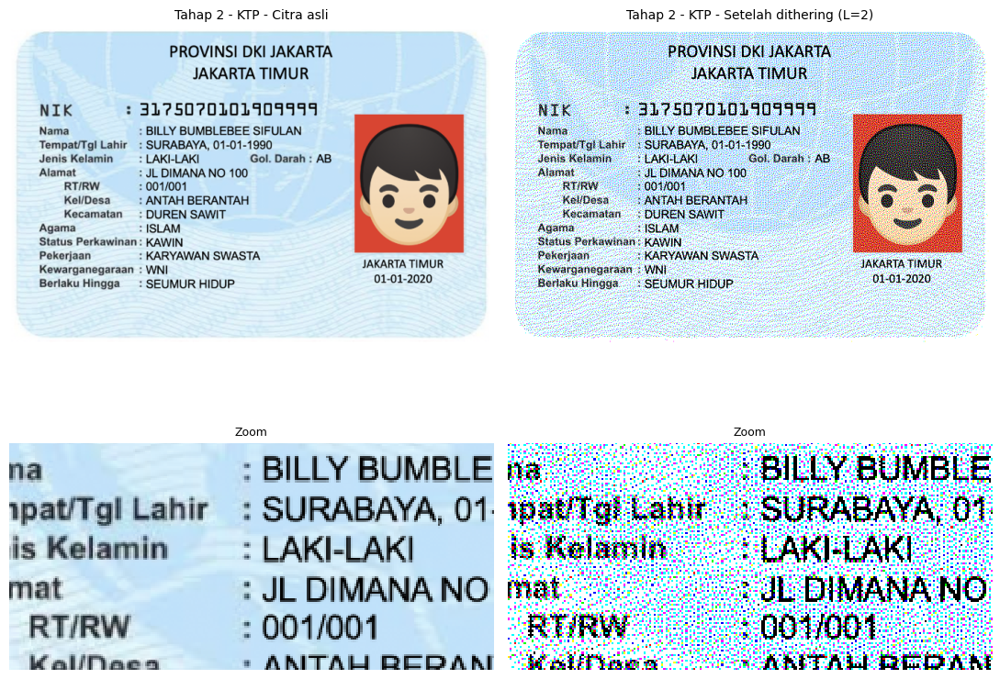

Tahap 2 - KTP: L = 2, jumlah warna unik asli = 27767, setelah dithering = 8 (maks 8)


In [20]:
tugas = [('Tahap 1 - Lena', BASE + '/lena.jpg', L_LENA_WARNA),
         ('Tahap 2 - KTP',  BASE + '/ktp1.jpg', PARAM['L'])]

for judul, path, L in tugas:
    bgr = baca(path)
    dith = fs_warna(bgr, L)

    H, W = bgr.shape[:2]
    zy1, zy2, zx1, zx2 = int(0.30*H), int(0.55*H), int(0.10*W), int(0.45*W)   # area zoom

    fig, ax = plt.subplots(2, 2, figsize=(11, 9))
    for j, (t, img) in enumerate([('Citra asli', bgr), (f'Setelah dithering (L={L})', dith)]):
        rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        ax[0, j].imshow(rgb); ax[0, j].set_title(f'{judul} - {t}', fontsize=10); ax[0, j].axis('off')
        ax[1, j].imshow(rgb[zy1:zy2, zx1:zx2], interpolation='nearest')
        ax[1, j].set_title('Zoom', fontsize=9); ax[1, j].axis('off')
    plt.tight_layout(); plt.show()

    print(f'{judul}: L = {L}, jumlah warna unik asli = {len(np.unique(bgr.reshape(-1,3), axis=0))}, '
          f'setelah dithering = {len(np.unique(dith.reshape(-1,3), axis=0))} (maks {L**3})')

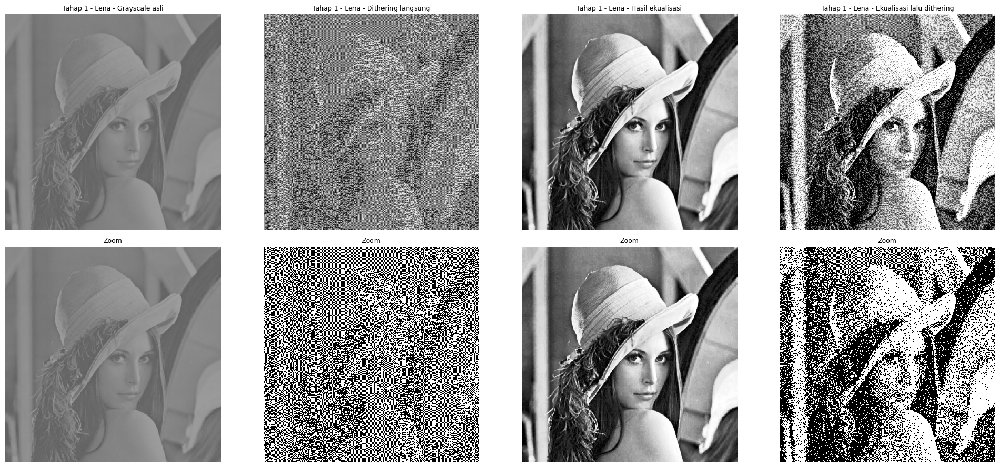

Tahap 1 - Lena (L = 2)
Citra                            Rerata   Std (area)   Level unik
Grayscale asli                    126.3         14.9           65
Dithering langsung                126.3        127.5            2
Hasil ekualisasi                  130.1         73.6           60
Ekualisasi lalu dithering         130.1        127.5            2



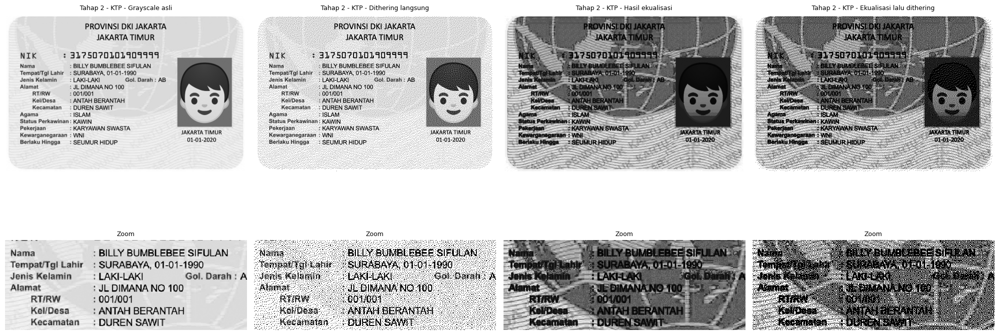

Tahap 2 - KTP (L = 2)
Citra                            Rerata   Std (area)   Level unik
Grayscale asli                    207.5         54.7          256
Dithering langsung                207.7        104.4            2
Hasil ekualisasi                  132.0         58.1           75
Ekualisasi lalu dithering         132.1        124.9            2



In [21]:
def uji_no2(judul, path, L, area=None):
    gray = baca(path, cv.IMREAD_GRAYSCALE)
    he = cv.equalizeHist(gray)
    d_he = floyd_steinberg(he, L)
    d_langsung = floyd_steinberg(gray, L)

    H, W = gray.shape
    y1, y2, x1, x2 = area if area else (0, H, 0, W)

    daftar = [('Grayscale asli', gray), ('Dithering langsung', d_langsung),
              ('Hasil ekualisasi', he), ('Ekualisasi lalu dithering', d_he)]

    fig, ax = plt.subplots(2, 4, figsize=(20, 9))
    for i, (t, img) in enumerate(daftar):
        ax[0, i].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0, i].set_title(f'{judul} - {t}', fontsize=9); ax[0, i].axis('off')
        ax[1, i].imshow(img[y1:y2, x1:x2], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax[1, i].set_title('Zoom', fontsize=9); ax[1, i].axis('off')
    plt.tight_layout(); plt.show()

    print(f'{judul} (L = {L})')
    print('%-28s %10s %12s %12s' % ('Citra', 'Rerata', 'Std (area)', 'Level unik'))
    for t, img in daftar:
        print('%-28s %10.1f %12.1f %12d' % (t, img.mean(), img[y1:y2, x1:x2].std(), len(np.unique(img))))
    print()

# Tahap 1: Lena (seluruh citra)
uji_no2('Tahap 1 - Lena', BASE + '/lena_lc.jpg', L_LENA_GRAY)

# Tahap 2: KTP (area zoom = teks NIK/Nama; sesuaikan pecahan bila belum pas)
g = baca(BASE + '/ktp1.jpg', cv.IMREAD_GRAYSCALE); H, W = g.shape
uji_no2('Tahap 2 - KTP', BASE + '/ktp1.jpg', PARAM['L'],
        area=(int(0.28*H), int(0.62*H), int(0.05*W), int(0.65*W)))

## Pertanyaan Praktikum E3 – Dithering Floyd-Steinberg

### 1. Dithering Floyd-Steinberg pada citra berwarna

Dithering dijalankan tiga kali, sekali untuk tiap kanal B, G, R (sesuai catatan flowchart), lalu ketiga kanal digabung kembali.

| Tahap | Citra | Jumlah level (L) | Warna unik asli | Warna unik setelah dithering |
|---|---|---|---|---|
| 1 | lena.jpg | 4 | 105621 | 41 (maks 64) |
| 2 | ktp1.jpg | 2 | 27767 | 8 (maks 8) |

Hasil Tahap 1 sudah sesuai dengan gambar contoh pada modul, sehingga kode dapat dilanjutkan ke Tahap 2. Setelah dithering, citra hanya memakai paling banyak L³ warna: pada Lena (L = 4) tersisa 41 dari maksimum 64 warna, dan pada KTP (L = 2) tersisa 8 warna, yaitu seluruh kombinasi hitam/putih tiap kanal. Meski warnanya sangat sedikit, citra tetap tampak mendekati aslinya karena error kuantisasi setiap piksel disebar ke tetangga (7/16 kanan, 3/16 kiri-bawah, 5/16 bawah, 1/16 kanan-bawah). Rata-rata warna di suatu daerah tetap terjaga, dan mata memadukan titik-titik berbeda warna menjadi warna perantara. Pada zoom terlihat pola titik-titik halus. Pada KTP dengan L = 2, latar biru muda berubah menjadi titik-titik berwarna primer yang tersebar, dan tepi huruf tampak bergerigi.

### 2. Grayscale + histogram equalization + dithering

### Tabel Pengukuran Citra KTP (L = 2)

| Citra KTP (ktp1.jpg, L = 2) | Rerata | Std area teks | Level unik |
| :--- | :---: | :---: | :---: |
| **Grayscale asli** | 207.5 | 54.7 | 256 |
| **Dithering langsung** | 207.7 | 104.4 | 2 |
| **Hasil ekualisasi** | 132.0 | 58.1 | 75 |
| **Ekualisasi lalu dithering** | 132.1 | 124.9 | 2 |

**Tahap 1 (lena_lc.jpg):** urutan ekualisasi lalu dithering sudah sesuai dengan gambar contoh. Citra lena_lc yang kontrasnya rendah (histogram sempit) menjadi jauh lebih hidup setelah ekualisasi, sedangkan dithering langsung tanpa ekualisasi masih tampak pucat.

**Mengapa ekualisasi dilakukan sebelum dithering?**
Dithering membulatkan setiap piksel ke salah satu dari L level. Bila histogram sempit (semua nilai berdekatan), sebagian besar piksel jatuh ke level yang sama sehingga variasi tonal hilang dan detail tidak muncul. Ekualisasi lebih dulu menyebar intensitas ke seluruh rentang 0-255, sehingga L level yang tersedia dipakai secara efektif. Sebaliknya, ekualisasi setelah dithering tidak berguna karena citra sudah hanya punya L nilai berbeda: ekualisasi hanya memetakan ulang L nilai itu dan tidak bisa memulihkan detail yang sudah hilang.

**Perbandingan pada KTP dan urutan yang paling terbaca:**

NIK dan nama lebih terbaca pada hasil **dithering langsung**. Citra ktp1.jpg asli sudah terang (rerata 207.5) dengan huruf gelap di atas latar terang, sehingga pemisah huruf dan latar sudah jelas dan bisa langsung dikuantisasi. Rerata hasil dithering langsung (207.7) hampir sama dengan citra asli, artinya sebagian besar area menjadi putih dan hanya huruf serta garis yang menjadi hitam. Sebaliknya, ekualisasi menurunkan kecerahan menjadi 132.0 dan memperkuat pola tekstur peta pada latar. Saat dikuantisasi ke 2 level, latar yang tadinya terang berubah menjadi campuran titik hitam dan putih (rerata 132.1, sekitar separuh piksel menjadi hitam), sehingga titik-titik latar bercampur dengan huruf dan teks tenggelam.

Nilai std area teks yang lebih tinggi pada ekualisasi lalu dithering (124.9 dibanding 104.4) tidak boleh dibaca sebagai keterbacaan yang lebih baik. Pada citra dua level, std yang tinggi hanya berarti proporsi piksel hitam dan putih makin seimbang. Di sini hal itu terjadi karena latar ikut menjadi berbintik hitam, bukan karena huruf lebih tegas.

Hasil ini sejalan dengan temuan sebelumnya bahwa ekualisasi global menggelapkan KTP ini dan tidak menambah keterbacaan teks. Ekualisasi juga mengurangi jumlah level unik dari 256 menjadi 75, karena histogram asli yang menumpuk di sisi terang diregangkan ke seluruh rentang sehingga banyak nilai hilang. Ekualisasi bermanfaat terutama untuk citra gelap atau berkontras rendah seperti lena_lc, bukan untuk citra yang sudah terang.

**Kesimpulan:** secara umum, ekualisasi dilakukan dulu baru dithering, karena dithering hanya mengubah cara error kuantisasi dibagi dan tidak menambah kontras. Namun efektivitasnya bergantung pada histogram citra asli. Pada Lena yang kontrasnya rendah, ekualisasi lebih dulu memberi hasil yang lebih baik. Pada KTP yang sudah terang dan berkontras baik, dithering langsung justru menghasilkan teks yang lebih terbaca.